# Read H-Reflex App Data Files (.hrs1 and .hrs2)

This notebook reads and visualizes data from the **H-Reflex Behavior App** binary data files:

- **`.hrs1`**  EMG Characterization stage data (Stage S1): contains trial-initiation monitored signals, binned EMG, and grand means.
- **`.hrs2`** MH Recruitment Curve stage data (Stage S2): contains peri-stimulus trial waveforms with stimulation amplitudes.

Both file types also store raw EMG data blocks (differential, filtered, absolute-valued signals).

The binary format is based on the `FileIO_Helpers` serialization from the `hreflex_txbdc` package.

# Section 1: Binary File Reader Utilities

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from helpers import (
    # File readers
    read_hrs1, read_hrs2, find_hrs_files,
    # Summary printers
    print_hrs1_summary, print_hrs2_summary,
    # HRS2 plots
    plot_amplitude_distribution, plot_background_emg_views, plot_hrs2_analysis,
    # SNR analysis
    compute_snr_analysis, compute_mra_snr_analysis,
    plot_hrs2_trials, classify_trials, get_trial_window,
    detect_stim_onset, get_trial_context_window,
    detect_and_correct_failed_trials,
    # Post-hoc global windowing analysis
    analyze_global_background, run_threshold_sweep, plot_threshold_sweep,
    split_trials_by_polarity, plot_hm_ratio_summary,
    # Constants
    SAMPLE_RATE, BIN_DURATION_MS, BIN_SAMPLES, TRIAL_RECORD_MS,
    STIM_ONSET_THRESHOLD, STIM_END_THRESHOLD,
)

print("Helpers loaded.")
print(f"  App constants: SAMPLE_RATE={SAMPLE_RATE} Hz | BIN={BIN_DURATION_MS} ms ({BIN_SAMPLES} samples) | TRIAL_RECORD={TRIAL_RECORD_MS} ms")
print(f"  Stim thresholds: onset >= {STIM_ONSET_THRESHOLD} V | end < {STIM_END_THRESHOLD} V")

Helpers loaded.
  App constants: SAMPLE_RATE=5000.0 Hz | BIN=50 ms (250 samples) | TRIAL_RECORD=100 ms
  Stim thresholds: onset >= 4.5 V | end < 1.9 V


# Section 2: Read and Explore the HRS1 File (EMG Characterization)

# Section 1b: Auto-Detect Recording Files

Set `recording_dir` to the path of your recording folder.  
The `.hrs1` and `.hrs2` files will be found automatically.

In [7]:
# ---- Set your recording directory here ----
# Set to the folder that contains your .hrs1 (and optionally .hrs2) files.
#
# Latest recordings (HRS2 v5, may include background_emg_mean + background_bins):
#   HRPILOT-17_EMG_CHARACTERIZATION_5-12-2026  -- HRS2 v5, 5 kHz, with background_bins
#   D1_5KHZ_HRPILOT16_B_5-11-26               -- HRS2 v5, 5 kHz, background_emg_mean only
#
# New-format HRPILOT recordings (HRS1 includes sample_rate field, HRS2 v4):
#   D1_HRPILOT16_A_5-11-26                    -- 10 kHz, HRS2 v4
#   D1_HRPILOT16_B_5-11-26                    -- 10 kHz, HRS2 v4
#   HRPILOT-16-CONFIGA_RECRUITMENTCURVE_      -- first recruitment curve  (HRS2 v2)
#   HRPILOT-16-CONFIGA_2ND_RECRUITMENTCURVE_  -- second recruitment curve (HRS2 v3, unipolar)
#
# Legacy polarity / hour-test recordings (no sample_rate in HRS1 header):
#   Polarity_Tests/HR-08-POLARITY_TEST_CORRECT   -- electrodes attached correctly
#   Polarity_Tests/HR-08-POLARITY_TEST_FLIPPED_  -- electrodes attached flipped
#   Polarity_Tests/HR-08-HOUR_TEST_              -- HRS1 only (no HRS2 file)

recording_dir = "D1_A_HRPILOT_17_TEST_5-27-26"
recording_sample_rate = 15000  # Set to e.g. 5000.0 or 10000.0 to override; None = auto-detect from HRS1 header

hrs1_path, hrs2_path = find_hrs_files(recording_dir)
print(f"Recording directory: {recording_dir}")
print(f"  HRS1 file: {os.path.basename(hrs1_path)}")
if hrs2_path is not None:
    print(f"  HRS2 file: {os.path.basename(hrs2_path)}")
else:
    print("  HRS2 file: not found â HRS2 sections will be skipped")


Recording directory: D1_A_HRPILOT_17_TEST_5-27-26
  HRS1 file: D1_A_HRPILOT_17_TEST_5-27-26_20260527T130627.hrs1
  HRS2 file: D1_A_HRPILOT_17_TEST_5-27-26_20260527T130925.hrs2


In [8]:
# ---- Read the HRS1 file (auto-detected) ----
hrs1_header, hrs1_trials, hrs1_emg_blocks = read_hrs1(hrs1_path)
print_hrs1_summary(hrs1_header, hrs1_trials, hrs1_emg_blocks, hrs1_path)

=== HRS1 Header ===
  File:               D1_A_HRPILOT_17_TEST_5-27-26_20260527T130627.hrs1
  File version:       1
  Subject ID:         D1_A_HRPILOT_17_TEST_5-27-26
  Session datetime:   2026-05-27 13:06:27.627033
  Stage name:         S1
  Stage description:  EMG Characterization
  Stage type:         0
  Trial init uV min:  15.0
  Trial init uV max:  300.0
  Trial init phase min ms: 2200
  Trial init phase max ms: 2700
  Bin duration ms:    50
  Sample rate:        15000.0 Hz
  Trials/hr data: centre=205.27 µV, elapsed=0.004 h, 20 window sizes

  Trials found:       5
  EMG data blocks:    1123

=== First Trial ===
  End datetime:       2026-05-27 13:06:30.163260
  Start index:        410307
  Grand mean:         140.6254
  Bins count:         51
  Monitored signal N: 38250

=== First EMG Block ===
  Channel names:      ['CH10', 'CH12', 'ADC1', 'ADC2', 'ADC3', 'ADC4', 'ADC5']
  Raw channels:       7 x 192 samples
  Diff samples:       192
  Filtered samples:   192
  Abs samples:   

# Section 3: Read and Explore the HRS2 File (MH Recruitment Curve)

In [9]:
# ---- Read the HRS2 file (auto-detected) ----
if hrs2_path is None:
    print("No HRS2 file found — skipping HRS2 read.")
    hrs2_header, hrs2_trials, hrs2_emg_blocks = None, [], []
else:
    hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs2_path)
    print_hrs2_summary(hrs2_header, hrs2_trials, hrs2_emg_blocks, hrs2_path)

=== HRS2 Header ===
  File:               D1_A_HRPILOT_17_TEST_5-27-26_20260527T130925.hrs2
  File version:       7  (v7: + digital_onset_sample_num/channel)
  Subject ID:         D1_A_HRPILOT_17_TEST_5-27-26
  Session start time: 2026-05-27 13:09:26.178901
  Stage name:         S2
  Stage description:  Mh Recruitment Curve
  Stage type:         1

  Trials found:       2444
  EMG data blocks:    669975
  Stim polarity:      1002 normal, 1442 reversed  <-- dual-polarity session
  Digital onsets:     0/2444 trials have digital onset  <-- none detected

=== First EMG Block ===
  Channel names:  ['CH10', 'CH12', 'ADC1', 'ADC2', 'ADC3', 'ADC4', 'ADC5']
  Raw channels:   7 x 192 samples
  Diff samples:   192


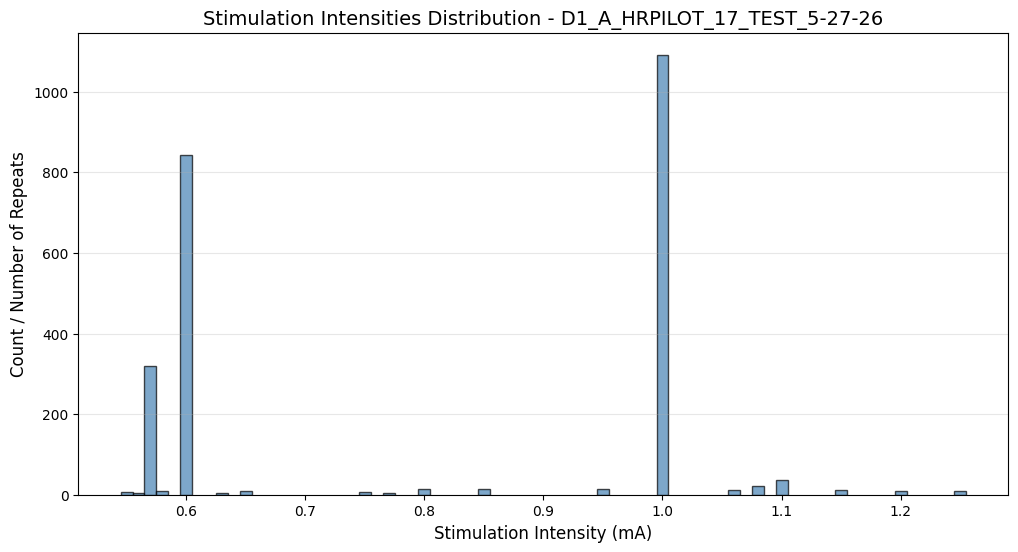

In [10]:
# ---- Histogram of stimulation intensities ----
plot_amplitude_distribution(hrs2_trials, hrs2_header)

# Section 3b: "Most Recent Background" + "Background EMG Level"

Recreates the H-Reflex App recruitment-curve trial-plot widgets from `MhRecruitmentCurveStage.get_trial_plot_options`:

- **Most recent background** — bar chart of the pre-stim |EMG| bins.
- **EMG Level** — scatter of background grand means across trials.

Bins are reconstructed from `hrs2_emg_blocks` over a fixed monitoring window (default 2500 ms ending at trigger time).

In [11]:
# ---- "Most recent background" + "Background EMG Level" plots ----
# Mirrors the H-Reflex App recruitment-curve trial plot widgets.
plot_background_emg_views(hrs2_trials, hrs2_emg_blocks, monitoring_window_ms=2500)

2444 trials used stored bins  |  0 trials reconstructed from emg_blocks.


# Section 6: HRS2 Detailed Analysis

Interactive averaged-waveform paged grid (with M/H peak markers and signal overlays) plus the normalized and raw recruitment curves. The cell below sets the analysis parameters; the cell after that calls `plot_hrs2_analysis`.

In [12]:
#  Configuration 
PRE_PLOT_MS  = 15   # ms before stim onset to display
POST_PLOT_MS = 15  # ms after  stim onset to display
N_PER_PAGE   = 6   # trials shown per page (2 rows x 3 cols)

# M/H wave window constants (ms relative to stim onset)
#M_WAVE_START_MS = 3
#M_WAVE_END_MS= 5.5
#H_WAVE_START_MS = 9.0
#H_WAVE_END_MS   = 12

M_WAVE_START_MS = 2 
M_WAVE_END_MS= 5 
H_WAVE_START_MS = 6
H_WAVE_END_MS   = 10

PRE_AVG_MS  = 15   # ms before stim onset
POST_AVG_MS = 15  # ms after  stim onset
N_PER_PAGE  = 6   # amplitude groups per page (2 rows x 3 cols)


In [13]:
# ---- HRS2 Analysis: Interactive Averaged Waveforms + Recruitment Curve ----
plot_hrs2_analysis(
    hrs2_trials, hrs2_header,
    pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
    n_per_page=N_PER_PAGE,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

Loaded 1 amplitude groups across 1 page(s)  — dual-polarity session: 1002 normal, 1442 reversed.
Double-click a subplot to zoom in. Ctrl-click to select multiple signals.


Output()

c:\Users\dal866445\Documents\Github\open-ephys-python-tools\.venv\Lib\site-packages\scipy\interpolate\_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


In [14]:
# ---- HRS2 Trial Viewer: Interactive Per-Trial Grid + Zoom ----
plot_hrs2_trials(
    hrs2_trials, hrs2_header,
    pre_plot_ms=PRE_PLOT_MS, post_plot_ms=POST_PLOT_MS,
    n_per_page=N_PER_PAGE,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

Loaded 1002 trials across 167 page(s)  — dual-polarity session: 1002 normal, 1442 reversed.
Sample rate: 15000 Hz  |  ms/sample: 0.0667
Stim waveform: available
Double-click a subplot to zoom in, or use the dropdown + 'View trial' button.


# Section 3c: H:M Ratio Summary

Box plot and histogram of H:M ratio for each stimulation polarity group.
If both normal and reversed polarities were used in this session, each group is analysed separately.

Dual-polarity session detected: 1002 normal, 1442 reversed → analysing separately.


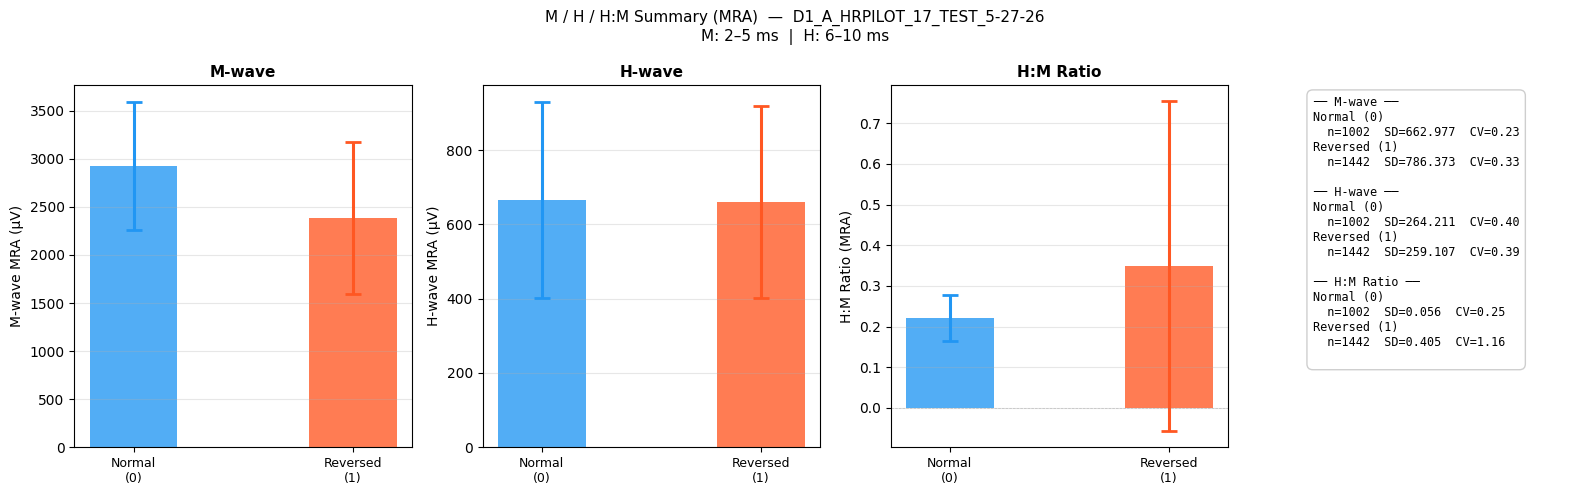

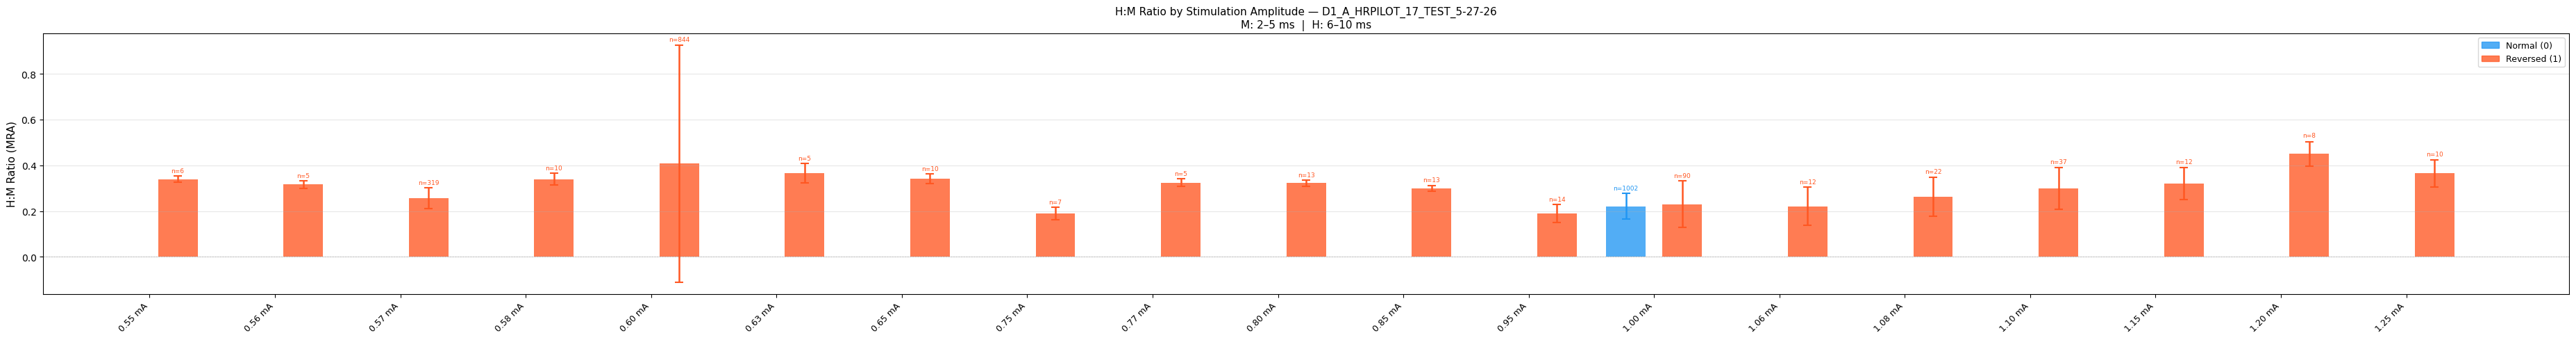

In [15]:
# ---- Stim polarity split ----
trials_by_polarity = split_trials_by_polarity(hrs2_trials)

# ---- H:M Ratio Summary: box plot + histogram ----
plot_hm_ratio_summary(
    trials_by_polarity, hrs2_header,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
    pre_ms=PRE_AVG_MS, post_ms=POST_AVG_MS,
)

# Section 7: Signal-to-Noise Ratio Analysis

For each trial three RMS-based SNR values are computed relative to the **RMS of the 15 ms pre-stimulus background**:

| SNR metric | Formula |
|---|---|
| **SNR_M** | RMS(M-wave window) / RMS(15 ms pre-stim BG) |
| **SNR_H** | RMS(H-wave window) / RMS(15 ms pre-stim BG) |
| **SNR_H:M** | (RMS_H / RMS_M) / RMS(15 ms pre-stim BG) |

M and H windows use the same time boundaries defined in Section 6 above.  
Adjust `BG_PRE_MS` below to change the background window length.

SNR Analysis — D1_A_HRPILOT_17_TEST_5-27-26
  M window : 2–5 ms
  H window : 6–10 ms
  BG window: -15–0 ms (pre-stim)

Metric                 n      Mean    Median        SD      CV
--------------------------------------------------------------
  SNR_M  (M/BG)     2444    71.847    24.039   138.828   1.932
  SNR_H  (H/BG)     2444    21.081     5.710    44.760   2.123
  SNR_HM (H:M/BG)   2444     0.007     0.002     0.014   1.999


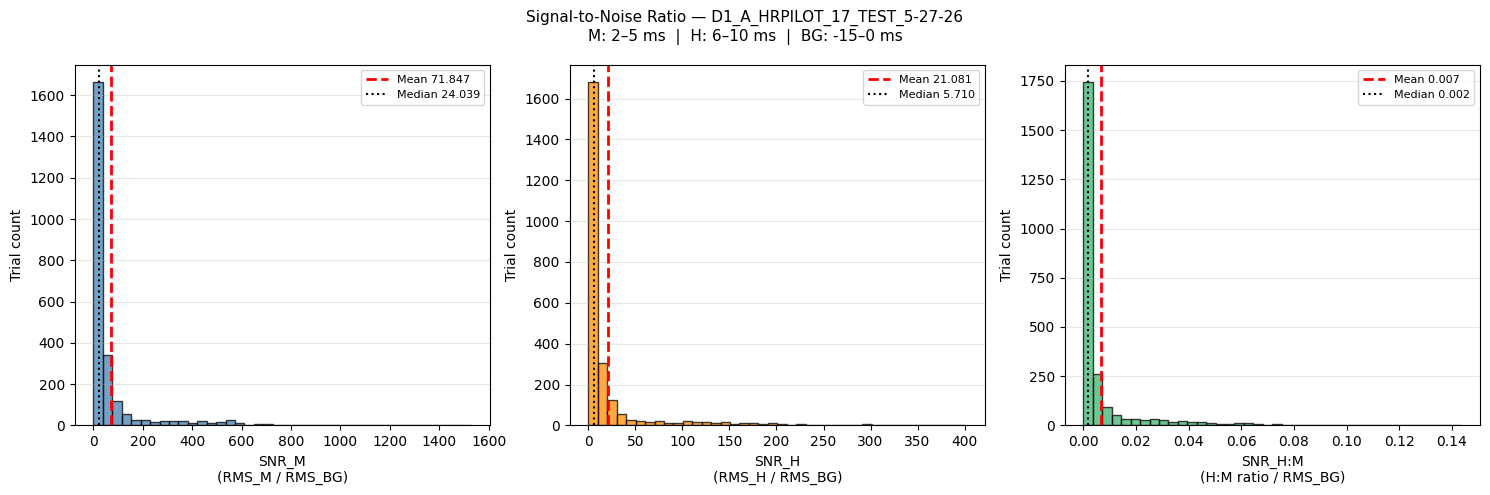

In [16]:
# ---- Section 7: Signal-to-Noise Ratio ----
# Background window length (ms before stim onset). Default = 15 ms.
BG_PRE_MS = 15.0

snr_results = compute_snr_analysis(
    hrs2_trials, hrs2_header,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    bg_pre_ms=BG_PRE_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)

# Section 8: Signal-to-Noise Ratio Analysis (Mean Rectified Average)

Same SNR analysis as Section 7, but using **Mean Rectified Average (MRA)** — `mean(|signal|)` — instead of RMS for all measurements.

| SNR metric | Formula |
|---|---|
| **MRA-SNR_M** | MRA(M-wave window) / MRA(15 ms pre-stim BG) |
| **MRA-SNR_H** | MRA(H-wave window) / MRA(15 ms pre-stim BG) |
| **MRA-SNR_H:M** | (MRA_H / MRA_M) / MRA(15 ms pre-stim BG) |

MRA-SNR Analysis — D1_A_HRPILOT_17_TEST_5-27-26
  M window : 2–5 ms
  H window : 6–10 ms
  BG window: -15–0 ms (pre-stim)

Metric                   n      Mean    Median        SD      CV
----------------------------------------------------------------
  MRA-SNR_M  (M/BG)   2444    77.301    24.795   147.314   1.906
  MRA-SNR_H  (H/BG)   2444    23.046     6.042    48.157   2.090
  MRA-SNR_HM (H:M/BG)  2444     0.009     0.002     0.018   1.961


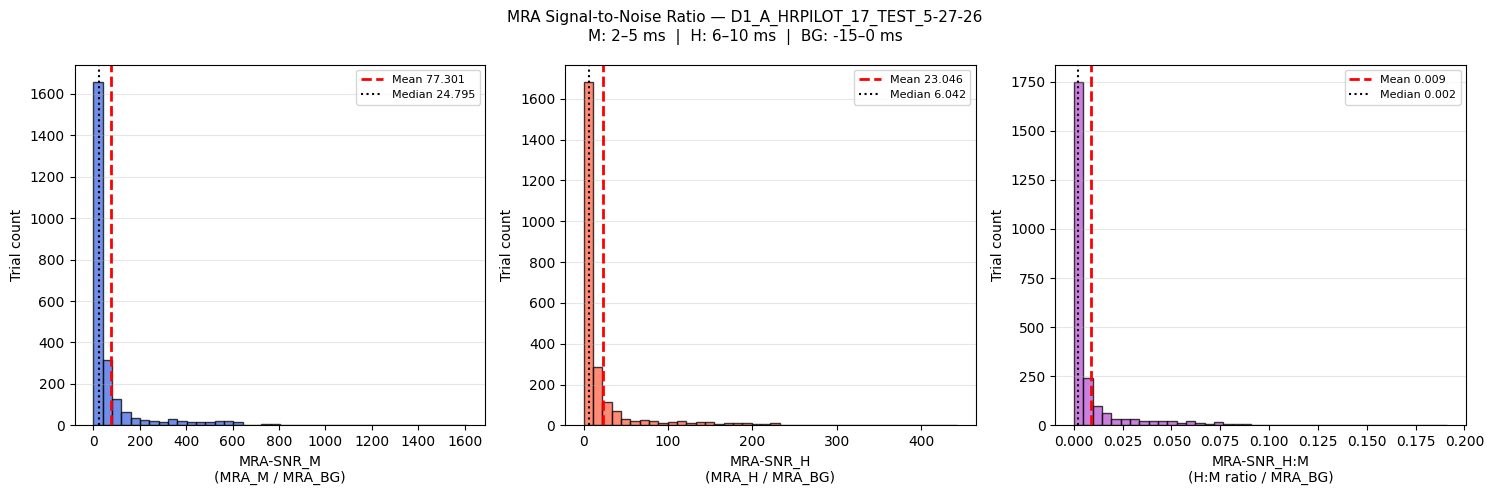

In [17]:
# ---- Section 8: MRA Signal-to-Noise Ratio ----
# Background window length (ms before stim onset). Default = 15 ms.
BG_PRE_MS = 15.0

mra_snr_results = compute_mra_snr_analysis(
    hrs2_trials, hrs2_header,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    bg_pre_ms=BG_PRE_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)